#  Классификация изображений с помощью сверточных нейронных сетей

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.html#convolution-layers
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://kozodoi.me/blog/20210308/compute-image-stats
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.matshow.html

In [1]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import numpy as np
import zipfile
import random

## Задачи для совместного разбора

1\. Рассмотрите основные возможности по созданию датасетов из `torchvision` и примеры работы основных слоев для создания сверточных нейронных сетей для анализа изображений.

2\. Реализуйте типовую архитектуру CNN для классификации изображений.

## Задачи для самостоятельного решения

In [2]:
zip_path = 'cat_breeds_4.zip'
extract_path = '/content'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
transform1 = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor()
    ])

In [4]:
dataset = datasets.ImageFolder(root='/content/cat_breeds_4', transform=transform1)
dataloader = DataLoader(dataset, batch_size = 256, shuffle = True)

<p class="task" id="1"></p>

1\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Используя преобразования `torchvision`, приведите картинки к размеру 300х300 и нормализуйте значения интенсивности пикселей (рассчитайте статистику для нормализации отдельно). Выведите на экран количество картинок в датасете,  размер одной картинки, количество уникальных классов. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

- [ ] Проверено на семинаре

In [5]:
mean = 0.0
std = 0.0
total_images_count = 0

for images, _ in dataloader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images_count += batch_samples

mean /= total_images_count
std /= total_images_count


In [6]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std)
    ])

In [7]:
dataset = datasets.ImageFolder(root='/content/cat_breeds_4', transform=transform)
dataloader = DataLoader(dataset, batch_size = 256, shuffle = True)

In [8]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [10]:
print(dataset.classes.__len__(), '- количество классов')
print(dataset[0][0].shape, '- размер фотографии')
print(mean, '- среднее по 3м каналам')
print(std, '- отклонение по 3м каналам')
print(total_images_count, '- количество фоток в датасете')

4 - количество классов
torch.Size([3, 300, 300]) - размер фотографии
tensor([0.5000, 0.4514, 0.4066]) - среднее по 3м каналам
tensor([0.2324, 0.2273, 0.2228]) - отклонение по 3м каналам
4000 - количество фоток в датасете


<p class="task" id="2"></p>

2\. Решите задачу классификации на основе датасета из предыдущего задания, не используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели.   

- [ ] Проверено на семинаре

In [11]:
L_model = nn.Sequential(
    nn.Flatten(),

    nn.Linear(3 * 300 * 300, 16),
    nn.ReLU(),

    nn.Linear(16, 64),
    nn.ReLU(),

    nn.Linear(64, 128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Linear(64, 16),
    nn.ReLU(),

    nn.Linear(16, 4)
).cpu()

crit = nn.CrossEntropyLoss()
optimizer = optim.Adam(params = L_model.parameters(), lr = 0.001)

train_losses = []
test_losses = []

In [12]:
def test_loss(model, test_loader):
    model.eval()
    loss_for_epoch = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            y_batch, x_batch = y_batch.cpu(), x_batch.cpu()
            y_pred = model(x_batch)
            loss = crit(y_pred, y_batch)
            loss_for_epoch += loss.item()
            _, predicted = torch.max(y_pred, 1)
            total_predictions += y_batch.size(0)
            correct_predictions += (predicted == y_batch).sum().item()

    loss_for_epoch /= len(test_loader)
    accuracy = correct_predictions / total_predictions
    return loss_for_epoch, accuracy

In [13]:
for epoch in range(5):
    train_loss_for_epoch = 0
    correct_train_predictions = 0
    total_train_predictions = 0

    for x_batch, y_batch in train_loader:
        y_batch, x_batch = y_batch.cpu(), x_batch.cpu()
        predict = L_model(x_batch)
        train_loss = crit(predict, y_batch)
        train_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss_for_epoch += train_loss.item()

        _, predicted = torch.max(predict, 1)
        total_train_predictions += y_batch.size(0)
        correct_train_predictions += (predicted == y_batch).sum().item()

    train_loss_for_epoch /= len(train_loader)
    train_losses.append(train_loss_for_epoch)

    test_loss_for_epoch, test_accuracy = test_loss(L_model, test_loader)
    test_losses.append(test_loss_for_epoch)

    train_accuracy = correct_train_predictions / total_train_predictions

    print(f"Epoch: {epoch + 1} | Train loss: {train_loss_for_epoch:.4f} | Train accuracy: {train_accuracy:.4f} | Test loss: {test_loss_for_epoch:.4f} | Test accuracy: {test_accuracy:.4f}")

Epoch: 1 | Train loss: 1.4055 | Train accuracy: 0.3116 | Test loss: 1.3711 | Test accuracy: 0.3275
Epoch: 2 | Train loss: 1.3033 | Train accuracy: 0.3959 | Test loss: 1.3789 | Test accuracy: 0.3412
Epoch: 3 | Train loss: 1.2664 | Train accuracy: 0.4128 | Test loss: 1.3480 | Test accuracy: 0.3350
Epoch: 4 | Train loss: 1.2002 | Train accuracy: 0.4666 | Test loss: 1.3737 | Test accuracy: 0.3375
Epoch: 5 | Train loss: 1.1666 | Train accuracy: 0.4788 | Test loss: 1.3633 | Test accuracy: 0.3775


In [14]:
for epoch in range(5):
    train_loss_for_epoch = 0
    correct_train_predictions = 0
    total_train_predictions = 0

    for x_batch, y_batch in train_loader:
        y_batch, x_batch = y_batch.cpu(), x_batch.cpu()
        predict = L_model(x_batch)
        train_loss = crit(predict, y_batch)
        train_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss_for_epoch += train_loss.item()

        _, predicted = torch.max(predict, 1)
        total_train_predictions += y_batch.size(0)
        correct_train_predictions += (predicted == y_batch).sum().item()

    train_loss_for_epoch /= len(train_loader)
    train_losses.append(train_loss_for_epoch)

    test_loss_for_epoch, test_accuracy = test_loss(L_model, test_loader)
    test_losses.append(test_loss_for_epoch)

    train_accuracy = correct_train_predictions / total_train_predictions

    print(f"Epoch: {epoch + 6} | Train loss: {train_loss_for_epoch:.4f} | Train accuracy: {train_accuracy:.4f} | Test loss: {test_loss_for_epoch:.4f} | Test accuracy: {test_accuracy:.4f}")

Epoch: 6 | Train loss: 1.0968 | Train accuracy: 0.5141 | Test loss: 1.4470 | Test accuracy: 0.3450
Epoch: 7 | Train loss: 1.0475 | Train accuracy: 0.5375 | Test loss: 1.4442 | Test accuracy: 0.3575
Epoch: 8 | Train loss: 0.9757 | Train accuracy: 0.5778 | Test loss: 1.5319 | Test accuracy: 0.3675
Epoch: 9 | Train loss: 0.9249 | Train accuracy: 0.6041 | Test loss: 1.5560 | Test accuracy: 0.3450
Epoch: 10 | Train loss: 0.8540 | Train accuracy: 0.6422 | Test loss: 1.6015 | Test accuracy: 0.3663


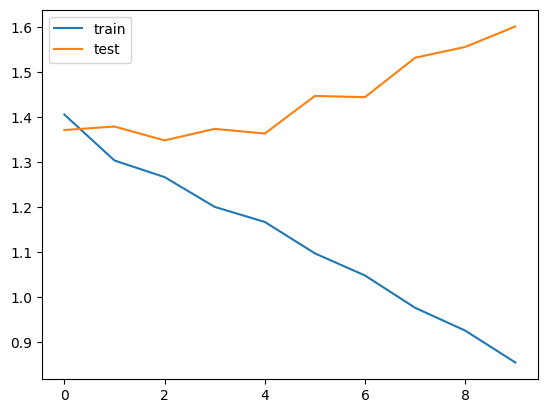

In [15]:
plt.plot(train_losses, label = 'train')
plt.plot(test_losses, label = 'test')
plt.legend()
plt.show()

In [16]:
total_params = sum(p.numel() for p in L_model.parameters())
print(total_params,'- количество параметров')

4338788 - количество параметров


<p class="task" id="3"></p>

3\. Напишите функцию, которая выбирает несколько изображений из переданного набора данных и выводит их на экран в виде сетки с указанием над ними названия правильного класса и класса, предсказанного моделью. Воспользовавшись данной функцией, выведите прогнозы итоговой модели из предыдущей задачи по 6 случайным картинкам.

```
def show_examples(model, dataset, k=6):
    pass
```

- [ ] Проверено на семинаре

In [17]:
def show_examples(model, dataset, full_dataset, k=6):
    model.eval()
    fig, axs = plt.subplots(1, k, figsize=(15, 5))

    inv_transform = transforms.Compose([
        transforms.Normalize(
            mean=[-m / s for m, s in zip(mean, std)],
            std=1 / std
        )
    ])

    indices = random.sample(range(len(dataset)), k)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = dataset[idx]
            image = image.unsqueeze(0).cpu()

            output = model(image)
            _, predicted = torch.max(output, 1)

            image = inv_transform(image.squeeze().cpu())

            axs[i].imshow(image.permute(1, 2, 0).clamp(0, 1))
            axs[i].axis('off')

            true_label = full_dataset.classes[label]
            pred_label = full_dataset.classes[predicted.item()]
            axs[i].set_title(f"True: {true_label}\nPred: {pred_label}")

    plt.tight_layout()
    plt.show()


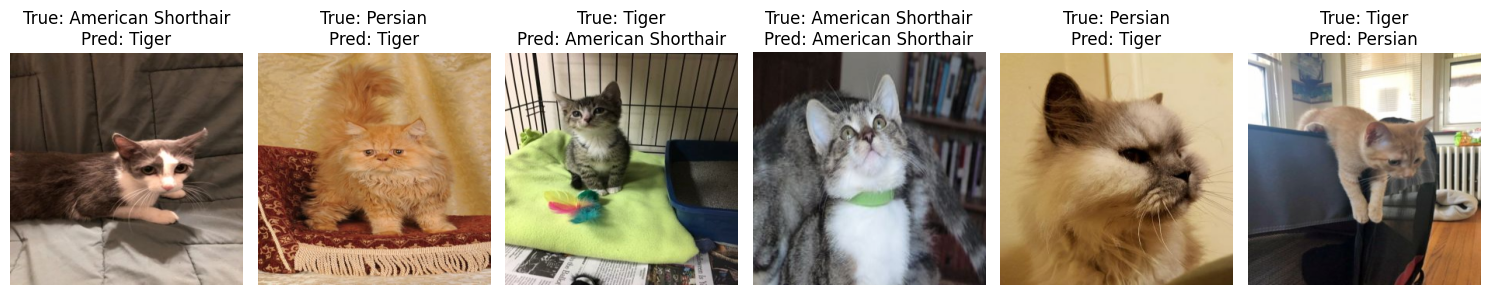

In [18]:
show_examples(L_model, test_dataset, dataset, k=6)

<p class="task" id="4"></p>

4\. Решите задачу классификации на основе датасета из первого задания, используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели. Воспользовавшись функцией из предыдущего задания, выведите прогнозы итоговой модели по 6 случайным картинкам.

- [ ] Проверено на семинаре

In [19]:
N_model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),


    nn.Flatten(),


    nn.Linear(16 * 75 * 75, 64),
    nn.ReLU(),


    nn.Linear(64, 4),
).cpu()

crit = nn.CrossEntropyLoss()
optimizer = optim.Adam(params = N_model.parameters(), lr = 0.001)

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

In [20]:
for epoch in range(10):
    train_loss_for_epoch = 0
    correct_train_predictions = 0
    total_train_predictions = 0

    for x_batch, y_batch in train_loader:
        y_batch, x_batch = y_batch.cpu(), x_batch.cpu()
        predict = N_model(x_batch)
        train_loss = crit(predict, y_batch)
        train_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss_for_epoch += train_loss.item()

        _, predicted = torch.max(predict, 1)
        total_train_predictions += y_batch.size(0)
        correct_train_predictions += (predicted == y_batch).sum().item()

    train_loss_for_epoch /= len(train_loader)
    train_losses.append(train_loss_for_epoch)

    test_loss_for_epoch, test_accuracy = test_loss(N_model, test_loader)
    test_losses.append(test_loss_for_epoch)
    test_accuracies.append(test_accuracy)

    train_accuracy = correct_train_predictions / total_train_predictions
    train_accuracies.append(train_accuracy)

    print(f"Epoch: {epoch + 1} | Train loss: {train_loss_for_epoch:.4f} | Train accuracy: {train_accuracy:.4f} | Test loss: {test_loss_for_epoch:.4f} | Test accuracy: {test_accuracy:.4f}")

Epoch: 1 | Train loss: 1.4025 | Train accuracy: 0.3022 | Test loss: 1.3453 | Test accuracy: 0.3950
Epoch: 2 | Train loss: 1.2006 | Train accuracy: 0.4997 | Test loss: 1.2076 | Test accuracy: 0.4550
Epoch: 3 | Train loss: 1.0334 | Train accuracy: 0.5728 | Test loss: 1.1568 | Test accuracy: 0.4775
Epoch: 4 | Train loss: 0.8335 | Train accuracy: 0.6875 | Test loss: 1.2199 | Test accuracy: 0.4950
Epoch: 5 | Train loss: 0.6017 | Train accuracy: 0.7894 | Test loss: 1.3555 | Test accuracy: 0.4775
Epoch: 6 | Train loss: 0.3700 | Train accuracy: 0.8838 | Test loss: 1.5308 | Test accuracy: 0.4650
Epoch: 7 | Train loss: 0.2146 | Train accuracy: 0.9472 | Test loss: 1.7969 | Test accuracy: 0.4512
Epoch: 8 | Train loss: 0.1089 | Train accuracy: 0.9828 | Test loss: 2.3418 | Test accuracy: 0.4375
Epoch: 9 | Train loss: 0.0551 | Train accuracy: 0.9944 | Test loss: 2.2936 | Test accuracy: 0.4650
Epoch: 10 | Train loss: 0.0262 | Train accuracy: 0.9984 | Test loss: 2.6507 | Test accuracy: 0.4725


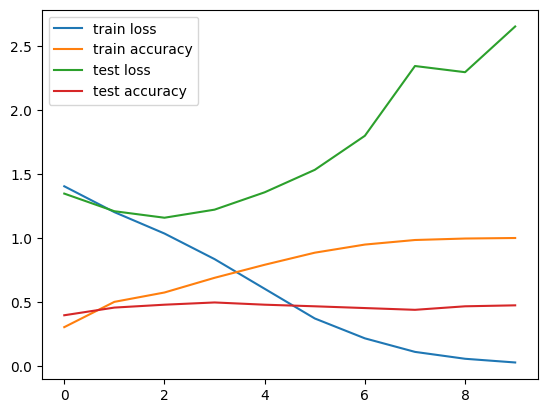

In [21]:
plt.plot(train_losses, label = 'train loss')
plt.plot(train_accuracies, label = 'train accuracy')
plt.plot(test_losses, label = 'test loss')
plt.plot(test_accuracies, label = 'test accuracy')
plt.legend()
plt.show()

In [22]:
total_params = sum(p.numel() for p in N_model.parameters())
print(total_params,'- количество параметров')

5764036 - количество параметров


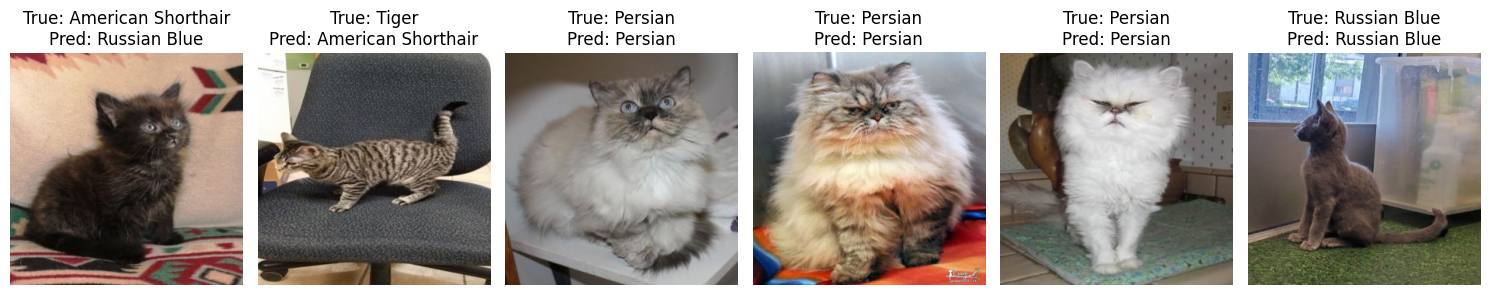

In [23]:
show_examples(N_model, test_dataset, dataset, k=6)

<p class="task" id="5"></p>

5\. Проанализируйте обученную в предыдущей задаче модель, исследовав обученные ядра сверточных слоев. Выберите одно изображение из тестового набора данных и пропустите через первый сверточный слой модели. Визуализируйте полученные карты признаков.

- [ ] Проверено на семинаре

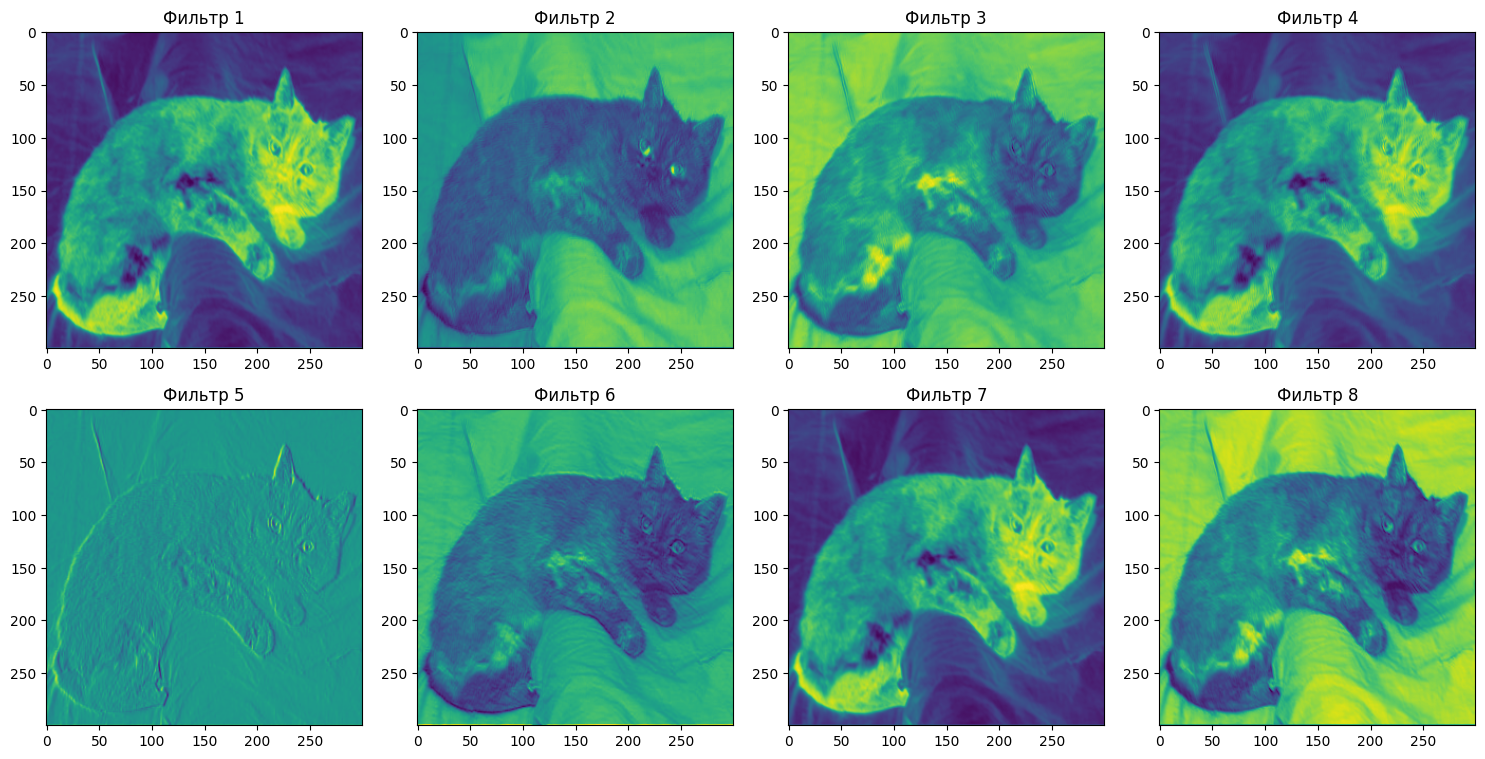

In [24]:
test_iter = iter(test_loader)
sample_batch, _ = next(test_iter)
sample_image = sample_batch[0].unsqueeze(0).cpu()

with torch.no_grad():
    first_conv_layer = N_model[0]
    feature_maps = first_conv_layer(sample_image)

feature_maps = feature_maps.cpu().squeeze().detach()

num_feature_maps = feature_maps.shape[0]
plt.figure(figsize=(15, 15))

for i in range(num_feature_maps):
    plt.subplot(4, 4, i+1)
    plt.imshow(feature_maps[i], cmap='viridis')
    plt.title(f'Фильтр {i+1}')

plt.tight_layout()
plt.show()

In [25]:
torch.save(N_model.state_dict(), 'model_04_1.pth')

## Обратная связь
- [ ] Хочу получить обратную связь по решению